# Tutorial 2 — Stepwise pathway over-representation analysis

In this tutorial we perform pathway over-representation analysis (ORA)
using the final ChemEquivMapper mapping results from the MTBLS1866
merged dataset.

Unlike Tutorial 1, no preprocessing or mapping is performed.

The tutorial uses two prepared files:

- metabolite_stats.tsv
- step5_isa_generalisation.tsv

The latter contains the identifier columns generated during
ChemEquivMapper Steps 1–4 and is therefore sufficient for performing
stepwise ORA.

## 1. Installation and imports


In [1]:
# Run once in a fresh Google Colab session
%pip install -q git+https://github.com/tiganouri/ChemEquivMapper.git

from pathlib import Path
import subprocess

REPO = Path("/content/ChemEquivMapper")
if not REPO.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/tiganouri/ChemEquivMapper.git", str(REPO)],
        check=True,
    )


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 55.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from ChemEquiv.analysis import StepwiseORA
from ChemEquiv.context import PipelineContext
from ChemEquiv.resources import *

## 2. Select the example dataset

The COVID-19 dataset is used because it consists of a single assay table and
therefore does not require assay merging.

To analyse a different dataset, replace `feature_table_path` and
`metadata_path` with the paths to your own files.

Expected feature-table format:

- the first column contains metabolite or feature names;
- all remaining columns contain sample abundances.

Expected metadata format:

- one row per sample;
- one sample-identifier column;
- one experimental-group column.


## 3. Load and inspect the statistical input

ChemEquivMapper's preprocessing stage produces one row per metabolite in `result.metabolite_stats`.

The `significant` column defines the ORA foreground. All mapped metabolites available at a given step form the corresponding background.

In [3]:
BASE = REPO / "tutorial_data" / "PROCESSED_grp_1866"

metabolite_stats = pd.read_csv(
    BASE / "metabolite_stats.tsv",
    sep="\t",
)

step5_df = pd.read_csv(
    BASE / "step5_isa_generalisation.tsv",
    sep="\t",
)

display(metabolite_stats.head())

display(step5_df.head())

,metabolite_id,p_value,method_used,n_features,n_per_group,p_adj,significant
0,DG(41:5),3.383124e-14,single,1,"HEALTHY:20,ICU-COVID-19:18",2.243011e-11,True
1,"1-(2,5-Dimethoxyphenyl)-1-[(trimethylsilyl)oxy...",1.452558e-13,single,1,"HEALTHY:20,ICU-COVID-19:18",4.815229e-11,True
2,FA(18:1),1.700299e-12,single,1,"HEALTHY:20,ICU-COVID-19:18",3.757660e-10,True
3,PC(17:1_18:2),1.672991e-11,single,1,"HEALTHY:20,ICU-COVID-19:18",2.772982e-09,True
4,"2,2,4,6,6-pentamethyl-Heptane",2.348977e-11,single,1,"HEALTHY:20,ICU-COVID-19:18",3.114744e-09,True


,Input name,RefMet_ID,Formula,Exact mass,Super class,Main class,Sub class,PubChem_CID,ChEBI_ID,HMDB_ID,...,CHEBI_is_a_Equivalents,CHEBI_ID_Step4,KEGG_ID_Step4,ChEBI_ID_Step4_reactome,Reactome_Pathways_Step4,KEGG_Compounds_Step4,KEGG_Pathways_Step4,CHEBI_IsA_Generalisation,Reactome_Pathways_IsA_Generalisation,n_pathways_isa_generalisation
0,DG(41:5),RM0134386,C44H76O5,684.5693,Glycerolipids,Diradylglycerols,DAG,NaN,NaN,NaN,...,NaN,CHEBI:132491,NaN,NaN,NaN,NaN,NaN,CHEBI:18035,"R-HSA-112043,R-HSA-1250196,R-HSA-192456,R-HSA-...",20
1,"1-(2,5-Dimethoxyphenyl)-1-[(trimethylsilyl)oxy...",-,-,-,-,-,-,-,NaN,-,...,NaN,CHEBI:183262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,FA(18:1),RM0140004,C18H34O2,282.2559,Fatty Acyls,Fatty acids,Unsaturated FA,NaN,NaN,NaN,...,"CHEBI:27997,CHEBI:28194,CHEBI:28727,CHEBI:3082...","CHEBI:16196,CHEBI:25634,CHEBI:27997,CHEBI:2819...","C00712,C01712,C08363,C08367","CHEBI:27997,CHEBI:30823","R-HSA-381771,R-HSA-416476,R-HSA-444209,R-HSA-1...",C00712,"map00061,map00073,map01040,map01060,map04212",NaN,NaN,0
3,PC(17:1_18:2),RM0025431,C43H80NO8P,769.5622,Glycerophospholipids,Glycerophosphocholines,PC,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,"2,2,4,6,6-pentamethyl-Heptane",-,-,-,-,-,-,-,NaN,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
# =========================================================
# Load pathway resources
# =========================================================

from ChemEquiv.context import PipelineContext
from ChemEquiv.resources import (
    ReactomeTXTConfig,
    KEGGTSVConfig,
)

reactome_txt = (
    REPO
    / "src"
    / "ChemEquiv"
    / "data"
    / "reactome"
    / "ChEBI2Reactome.txt"
)

kegg_tsv = (
    REPO
    / "src"
    / "ChemEquiv"
    / "data"
    / "kegg"
    / "kegg_compound_to_pathway.tsv"
)

ctx = (
    PipelineContext(repo_root=REPO)
    .load_resources_default(
        reactome_cfg=ReactomeTXTConfig(
            source="local",
            local_txt_path=reactome_txt,
        ),
        kegg_cfg=KEGGTSVConfig(
            source="local",
            local_tsv_path=kegg_tsv,
        ),
        species="Homo sapiens",
    )
)

print("✓ Reactome resources loaded")
print("✓ KEGG resources loaded")

✓ Reactome resources loaded
✓ KEGG resources loaded


## 4. Run stepwise ORA

`StepwiseORA.run_all_steps()` performs Reactome and KEGG enrichment analysis separately for the identifiers available after each mapping step.

This tutorial uses:

- right-tailed Fisher enrichment testing as implemented by ChemEquivMapper,
- `significant` as the foreground indicator,
- a minimum pathway size of 2 mapped identifiers.

In [5]:
ora = StepwiseORA(ctx=ctx)

ora_results = ora.run_all_steps(
    meta_df=step5_df,
    metabolite_stats=metabolite_stats,
    steps=[1, 2, 3, 4],
    meta_join_col="Input name",
    stats_join_col="metabolite_id",
    sig_col="significant",
    min_pathway_size=2,
)

print("Completed ORA for steps:", sorted(ora_results))

Completed ORA for steps: [1, 2, 3, 4]


## 5. Build a stepwise ORA summary

Column names may vary slightly between package versions. The helper below detects common p-value and adjusted-p-value names without modifying the original result tables.

In [6]:
def find_first_column(df, candidates):
    lower_to_original = {
        str(column).lower(): column
        for column in df.columns
    }

    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]

    return None


def summarise_ora_table(df, alpha=0.05):
    p_col = find_first_column(
        df,
        [
            "p_value",
            "pvalue",
            "p",
            "p-value",
        ],
    )

    q_col = find_first_column(
        df,
        [
            "q_value",
            "qvalue",
            "q",
            "fdr",
            "p_adj",
            "padj",
            "adjusted_p_value",
        ],
    )

    summary = {
        "Examined pathways": int(len(df)),
        "Nominally significant pathways": pd.NA,
        "FDR-significant pathways": pd.NA,
        "P-value column": p_col,
        "Adjusted P-value column": q_col,
    }

    if p_col is not None:
        p_values = pd.to_numeric(
            df[p_col],
            errors="coerce",
        )

        summary["Nominally significant pathways"] = int(
            (p_values < alpha).sum()
        )

    if q_col is not None:
        q_values = pd.to_numeric(
            df[q_col],
            errors="coerce",
        )

        summary["FDR-significant pathways"] = int(
            (q_values < alpha).sum()
        )

    return summary


summary_rows = []

for step, tables in ora_results.items():

    for database, table_key in [
        ("Reactome", "reactome_ora_chebi"),
        ("KEGG", "kegg_ora"),
    ]:
        table_summary = summarise_ora_table(
            tables[table_key],
            alpha=0.05,
        )

        summary_rows.append({
            "Step": int(step),
            "Database": database,
            **table_summary,
        })


ora_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["Database", "Step"])
    .reset_index(drop=True)
)

display(ora_summary)

,Step,Database,Examined pathways,Nominally significant pathways,FDR-significant pathways,P-value column,Adjusted P-value column
0,1,KEGG,111,1,0,p_value,q_value
1,2,KEGG,114,1,0,p_value,q_value
2,3,KEGG,114,1,0,p_value,q_value
3,4,KEGG,119,4,0,p_value,q_value
4,1,Reactome,18,1,0,p_value,q_value
5,2,Reactome,32,1,0,p_value,q_value
6,3,Reactome,86,3,0,p_value,q_value
7,4,Reactome,97,5,0,p_value,q_value


## 6. Plot pathway coverage across mapping steps

The solid lines show the number of pathways examined. Dashed lines show nominally significant pathways when a p-value column is available.

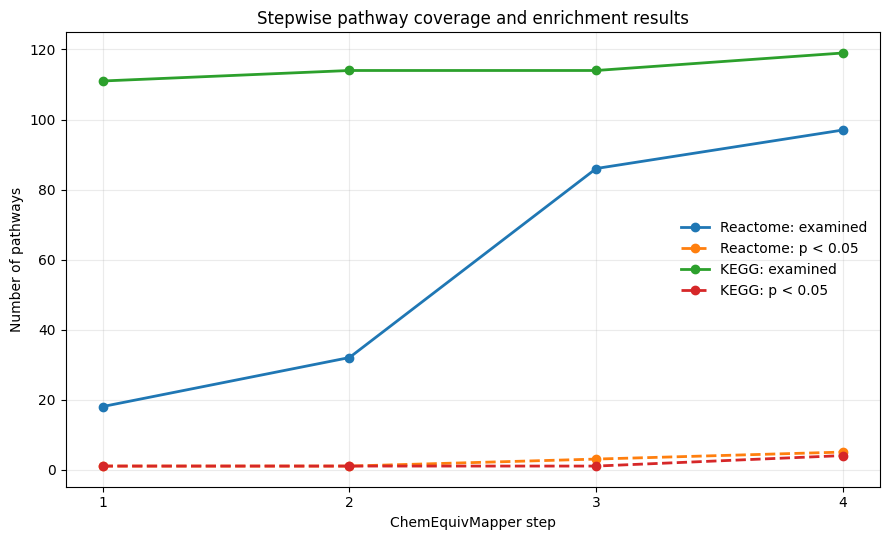

In [9]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(9, 5.5))

for database in ["Reactome", "KEGG"]:

    db_data = (
        ora_summary[
            ora_summary["Database"] == database
        ]
        .sort_values("Step")
    )

    ax.plot(
        db_data["Step"],
        db_data["Examined pathways"],
        marker="o",
        linewidth=2,
        label=f"{database}: examined",
    )

    significant = pd.to_numeric(
        db_data["Nominally significant pathways"],
        errors="coerce",
    )

    if significant.notna().any():
        ax.plot(
            db_data["Step"],
            significant,
            marker="o",
            linestyle="--",
            linewidth=2,
            label=f"{database}: p < 0.05",
        )


ax.set_xticks(sorted(ora_summary["Step"].unique()))
ax.set_xlabel("ChemEquivMapper step")
ax.set_ylabel("Number of pathways")
ax.set_title(
    "Stepwise pathway coverage and enrichment results"
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()

plt.show()

### 7. Inspect the most significant pathways

The next cell selects the most informative available significance column and displays the top pathways for each database and mapping step.

In [10]:
def top_ora_results(df, n=10):
    q_col = find_first_column(
        df,
        [
            "q_value",
            "qvalue",
            "q",
            "fdr",
            "p_adj",
            "padj",
            "adjusted_p_value",
        ],
    )

    p_col = find_first_column(
        df,
        [
            "p_value",
            "pvalue",
            "p",
            "p-value",
        ],
    )

    sort_col = q_col or p_col

    if sort_col is None:
        return df.head(n)

    result = df.copy()
    result[sort_col] = pd.to_numeric(
        result[sort_col],
        errors="coerce",
    )

    return (
        result
        .sort_values(sort_col, na_position="last")
        .head(n)
    )


for step in sorted(ora_results):

    print(f"\n{'=' * 70}")
    print(f"STEP {step}")
    print(f"{'=' * 70}")

    print("\nReactome")
    display(
        top_ora_results(
            ora_results[step]["reactome_ora_chebi"],
            n=10,
        )
    )

    print("\nKEGG")
    display(
        top_ora_results(
            ora_results[step]["kegg_ora"],
            n=10,
        )
    )


STEP 1

Reactome


,pathway_id,pathway_size,foreground_size,background_size,foreground_in_pathway,foreground_not_in_pathway,background_in_pathway_not_foreground,background_not_in_pathway_not_foreground,oddsratio,p_value,q_value
0,R-HSA-418594,4,59,143,4,55,0,84,inf,0.027250,0.433341
1,R-HSA-422085,2,59,143,2,57,0,84,inf,0.168522,0.433341
2,R-HSA-420499,2,59,143,2,57,0,84,inf,0.168522,0.433341
3,R-HSA-3296197,2,59,143,2,57,0,84,inf,0.168522,0.433341
4,R-HSA-112310,2,59,143,2,57,0,84,inf,0.168522,0.433341
5,R-HSA-5619108,2,59,143,2,57,0,84,inf,0.168522,0.433341
6,R-HSA-804914,2,59,143,2,57,0,84,inf,0.168522,0.433341
7,R-HSA-381753,3,59,143,2,57,1,83,2.912281,0.369313,0.656653
8,R-HSA-9717207,3,59,143,2,57,1,83,2.912281,0.369313,0.656653
9,R-HSA-381771,3,59,143,2,57,1,83,2.912281,0.369313,0.656653



KEGG


,pathway_id,pathway_size,foreground_size,background_size,foreground_in_pathway,foreground_not_in_pathway,background_in_pathway_not_foreground,background_not_in_pathway_not_foreground,oddsratio,p_value,q_value
0,map00061,7,42,98,6,36,1,55,9.166667,0.023184,0.609064
1,map04922,6,42,98,5,37,1,55,7.432432,0.050240,0.609064
2,map01063,10,42,98,7,35,3,53,3.533333,0.068262,0.609064
3,map00400,3,42,98,3,39,0,56,inf,0.075479,0.609064
4,map04024,3,42,98,3,39,0,56,inf,0.075479,0.609064
5,map00360,5,42,98,4,38,1,55,5.789474,0.104825,0.609064
6,map00720,5,42,98,4,38,1,55,5.789474,0.104825,0.609064
7,map00620,5,42,98,4,38,1,55,5.789474,0.104825,0.609064
8,map05230,19,42,98,11,31,8,48,2.129032,0.112173,0.609064
9,map01061,7,42,98,5,37,2,54,3.648649,0.117878,0.609064



STEP 2

Reactome


...

,pathway_id,pathway_size,foreground_size,background_size,foreground_in_pathway,foreground_not_in_pathway,background_in_pathway_not_foreground,background_not_in_pathway_not_foreground,oddsratio,p_value,q_value
0,map00061,8,69,158,7,62,1,88,9.935484,0.012975,0.726862
1,map00360,6,69,158,5,64,1,88,6.875000,0.057065,0.726862
2,map04922,6,69,158,5,64,1,88,6.875000,0.057065,0.726862
3,map01040,6,69,158,5,64,1,88,6.875000,0.057065,0.726862
4,map01063,10,69,158,7,62,3,86,3.236559,0.080413,0.726862
5,map00400,3,69,158,3,66,0,89,inf,0.081237,0.726862
6,map04024,3,69,158,3,66,0,89,inf,0.081237,0.726862
7,map00720,5,69,158,4,65,1,88,5.415385,0.114555,0.726862
8,map00620,5,69,158,4,65,1,88,5.415385,0.114555,0.726862
9,map01061,7,69,158,5,64,2,87,3.398438,0.130818,0.726862



STEP 4

Reactome


,pathway_id,pathway_size,foreground_size,background_size,foreground_in_pathway,foreground_not_in_pathway,background_in_pathway_not_foreground,background_not_in_pathway_not_foreground,oddsratio,p_value,q_value
0,R-HSA-5619108,7,781,1601,7,774,0,820,inf,0.006484,0.314452
1,R-HSA-804914,7,781,1601,7,774,0,820,inf,0.006484,0.314452
2,R-HSA-112310,6,781,1601,6,775,0,820,inf,0.013344,0.431441
3,R-HSA-418594,8,781,1601,7,774,1,819,7.406977,0.029831,0.578717
4,R-HSA-381771,8,781,1601,7,774,1,819,7.406977,0.029831,0.578717
5,R-HSA-444209,7,781,1601,6,775,1,819,6.340645,0.054504,0.591482
6,R-HSA-2453902,4,781,1601,4,777,0,820,inf,0.056406,0.591482
7,R-HSA-1989781,4,781,1601,4,777,0,820,inf,0.056406,0.591482
8,R-HSA-381340,4,781,1601,4,777,0,820,inf,0.056406,0.591482
9,R-HSA-433692,3,781,1601,3,778,0,820,inf,0.115857,0.591482



KEGG


,pathway_id,pathway_size,foreground_size,background_size,foreground_in_pathway,foreground_not_in_pathway,background_in_pathway_not_foreground,background_not_in_pathway_not_foreground,oddsratio,p_value,q_value
0,map01040,7,82,180,7,75,0,98,inf,0.003522,0.419125
1,map00061,8,82,180,7,75,1,97,9.053333,0.017488,0.689622
2,map00591,5,82,180,5,77,0,98,inf,0.018326,0.689622
3,map00010,4,82,180,4,78,0,98,inf,0.041352,0.689622
4,map01063,11,82,180,8,74,3,95,3.423423,0.059694,0.689622
5,map00360,6,82,180,5,77,1,97,6.298701,0.069641,0.689622
6,map04922,6,82,180,5,77,1,97,6.298701,0.069641,0.689622
7,map01061,8,82,180,6,76,2,96,3.789474,0.088789,0.689622
8,map01070,8,82,180,6,76,2,96,3.789474,0.088789,0.689622
9,map00400,3,82,180,3,79,0,98,inf,0.092650,0.689622


## Interpretation notes

When comparing steps, keep the following points in mind:

1. A larger number of examined pathways reflects increased identifier and pathway coverage.
2. A pathway can appear or disappear from the significant set as both the foreground and background identifier universes change.
3. Nominal significance (`p < 0.05`) and multiple-testing-adjusted significance are not equivalent.
4. Step 5 is a Reactome-focused generalisation step and should not be interpreted as an additional KEGG mapping stage.
5. Enrichment results should be interpreted together with effect direction, biological context, and the original metabolite-level statistics.

## What to do next

The next tutorial will demonstrate how to merge multiple analytical assays before preprocessing and ChemEquivMapper mapping.